# Thử nghiệm DWT trên ảnh có sương ngẫu nhiên

Notebook chọn ngẫu nhiên một ảnh trong các thư mục `hazy` của dataset, thực hiện DWT 2D một mức trên từng kênh RGB, trực quan hóa bốn dải tần và tái tạo ảnh bằng IDWT.

> Nếu môi trường chưa có thư viện cần thiết, chạy: `%pip install matplotlib PyWavelets`.

In [1]:
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pywt

plt.rcParams.update({"figure.figsize": (14, 8), "axes.titlesize": 12})

## 1. Chọn một ảnh có sương ngẫu nhiên

Đặt `SEED` thành một số nguyên nếu muốn lần chạy sau chọn lại đúng ảnh hiện tại; để `None` nếu muốn mỗi lần chạy chọn một ảnh mới.

Đã tìm thấy 1080 ảnh có sương.
Ảnh được chọn: dataset\Synthetic Objective Testing Set (SOTS) [RESIDE]\outdoor\train\hazy\0218_0.9_0.2.jpg
Kích thước dùng để xử lý: 550 x 412


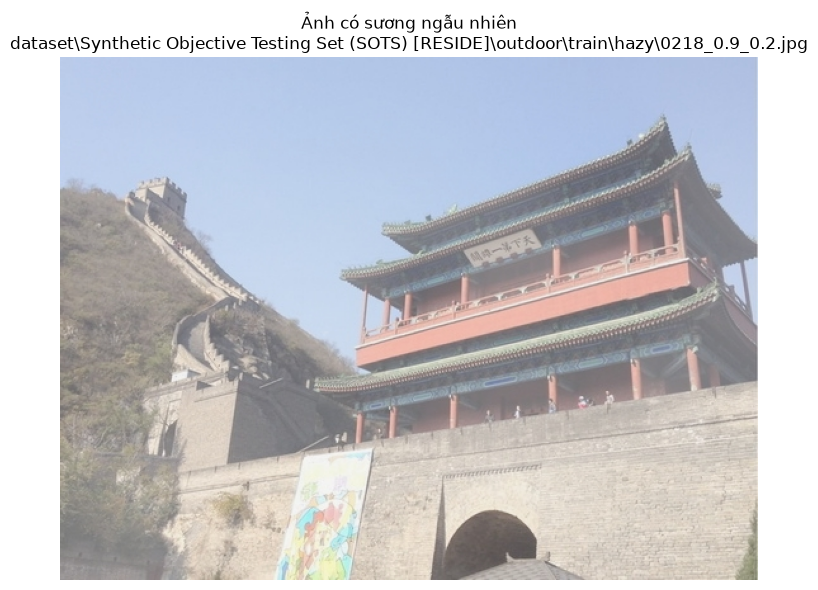

In [2]:
SEED = None
MAX_SIDE = 1200  # Giảm kích thước ảnh lớn để notebook chạy nhanh hơn.
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "dataset").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy thư mục dataset. Hãy chạy notebook bên trong repo.")

repo_root = find_repo_root()
hazy_images = sorted(
    path
    for path in (repo_root / "dataset").rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
    and path.parent.name.lower() == "hazy"
)

if not hazy_images:
    raise FileNotFoundError(f"Không tìm thấy ảnh trong các thư mục hazy tại {repo_root / 'dataset'}")

rng = random.Random(SEED)
image_path = rng.choice(hazy_images)
image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise ValueError(f"Không thể đọc ảnh: {image_path}")

height, width = image_bgr.shape[:2]
scale = min(1.0, MAX_SIDE / max(height, width))
if scale < 1.0:
    image_bgr = cv2.resize(
        image_bgr,
        (round(width * scale), round(height * scale)),
        interpolation=cv2.INTER_AREA,
    )

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
relative_path = image_path.relative_to(repo_root)
print(f"Đã tìm thấy {len(hazy_images)} ảnh có sương.")
print(f"Ảnh được chọn: {relative_path}")
print(f"Kích thước dùng để xử lý: {image_rgb.shape[1]} x {image_rgb.shape[0]}")

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.title(f"Ảnh có sương ngẫu nhiên\n{relative_path}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Phân rã DWT một mức

Với mỗi kênh màu, `dwt2` tạo ra:

- `LL` (`cA`): thành phần xấp xỉ, chứa cấu trúc và tần số thấp.
- `LH` (`cH`): chi tiết theo phương ngang.
- `HL` (`cV`): chi tiết theo phương dọc.
- `HH` (`cD`): chi tiết đường chéo và tần số cao.

In [3]:
WAVELET = "haar"
MODE = "symmetric"

coefficients = [
    pywt.dwt2(image_rgb[..., channel], wavelet=WAVELET, mode=MODE)
    for channel in range(3)
]

cA = np.stack([coeff[0] for coeff in coefficients], axis=-1)
cH = np.stack([coeff[1][0] for coeff in coefficients], axis=-1)
cV = np.stack([coeff[1][1] for coeff in coefficients], axis=-1)
cD = np.stack([coeff[1][2] for coeff in coefficients], axis=-1)

print(f"Wavelet: {WAVELET}, mode: {MODE}")
print(f"Ảnh gốc: {image_rgb.shape}; mỗi dải DWT: {cA.shape}")

Wavelet: haar, mode: symmetric
Ảnh gốc: (412, 550, 3); mỗi dải DWT: (206, 275, 3)


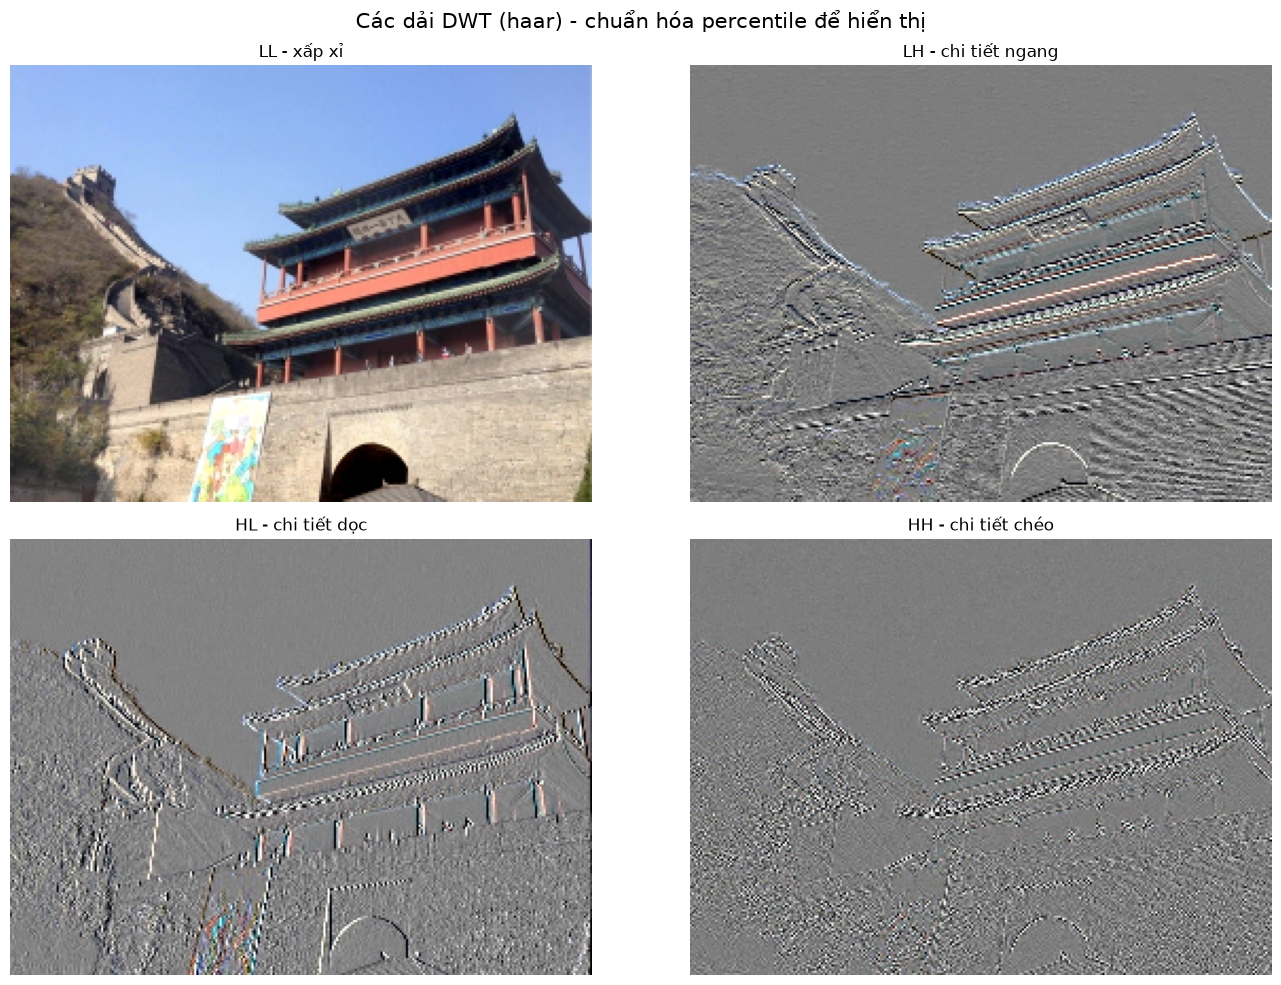

In [4]:
def normalize_for_display(array):
    low, high = np.percentile(array, (1, 99))
    if np.isclose(low, high):
        return np.zeros_like(array)
    return np.clip((array - low) / (high - low), 0, 1)

bands = {
    "LL - xấp xỉ": cA,
    "LH - chi tiết ngang": cH,
    "HL - chi tiết dọc": cV,
    "HH - chi tiết chéo": cD,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for axis, (title, band) in zip(axes.flat, bands.items()):
    axis.imshow(normalize_for_display(band))
    axis.set_title(title)
    axis.axis("off")

fig.suptitle(f"Các dải DWT ({WAVELET}) - chuẩn hóa percentile để hiển thị", fontsize=15)
plt.tight_layout()
plt.show()

## 3. Tái tạo ảnh bằng IDWT

Nếu giữ nguyên toàn bộ hệ số, ảnh tái tạo phải gần như trùng khớp ảnh đầu vào; sai số còn lại chủ yếu do tính toán số thực.

MSE: 4.999e-15
PSNR tái tạo: 143.01 dB
Sai số tuyệt đối lớn nhất: 2.384e-07


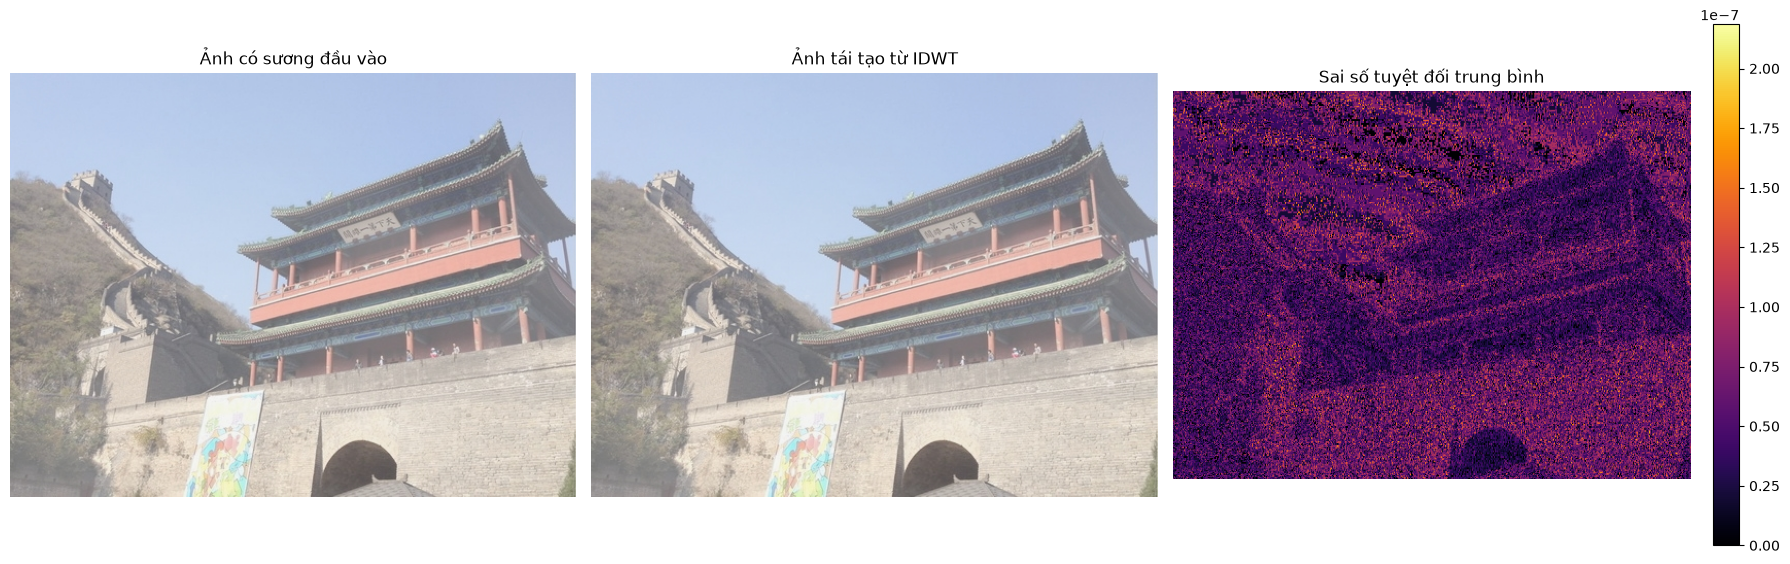

In [5]:
reconstructed_channels = [
    pywt.idwt2(coeff, wavelet=WAVELET, mode=MODE)
    for coeff in coefficients
]
reconstructed = np.stack(reconstructed_channels, axis=-1)
reconstructed = reconstructed[: image_rgb.shape[0], : image_rgb.shape[1]]
reconstructed = np.clip(reconstructed, 0, 1)

absolute_error = np.abs(image_rgb - reconstructed)
mse = float(np.mean((image_rgb - reconstructed) ** 2))
psnr = float("inf") if mse == 0 else 10 * np.log10(1.0 / mse)

print(f"MSE: {mse:.3e}")
print(f"PSNR tái tạo: {psnr:.2f} dB")
print(f"Sai số tuyệt đối lớn nhất: {absolute_error.max():.3e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image_rgb)
axes[0].set_title("Ảnh có sương đầu vào")
axes[1].imshow(reconstructed)
axes[1].set_title("Ảnh tái tạo từ IDWT")
error_plot = axes[2].imshow(absolute_error.mean(axis=2), cmap="inferno")
axes[2].set_title("Sai số tuyệt đối trung bình")
fig.colorbar(error_plot, ax=axes[2], fraction=0.046, pad=0.04)
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## Gợi ý thử thêm

- Đổi `WAVELET` sang `db2`, `sym4` hoặc `bior4.4`.
- Đặt các hệ số chi tiết về 0 trước IDWT để quan sát tác dụng làm trơn.
- Threshold các dải `LH`, `HL`, `HH` để thử khử nhiễu.
- Tăng số mức phân rã bằng `pywt.wavedec2`.